### [Tên dự án]: Dự Báo Giá Nhà (House Price Prediction)
---
## 1. Introduction
- Mục tiêu: Xây dựng mô hình Machine Learning để dự báo giá nhà.
- Dataset Source: (https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)
- The data consists of [`79`] columns and [`1460`] rows.
---

## 2. Exploratory Data Analysis - EDA
### 2.1. Import Data and Required Packages

In [2]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

Import the CSV Data

In [ ]:
df = pd.read_csv('./data/train.csv')

Show top 5 record

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Shape of dataset

In [ ]:
df.shape

(1460, 81)

Check Missing Value

In [ ]:
total = df.isna().sum().sort_values(ascending=False)
percent = (df.isna().sum()/len(df) * 100).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent (%)'])

print("Missing Data:")
print(missing_data[missing_data['Total'] > 0].head(20))

Missing Data:
              Total  Percent (%)
PoolQC         1453    99.520548
MiscFeature    1406    96.301370
Alley          1369    93.767123
Fence          1179    80.753425
MasVnrType      872    59.726027
FireplaceQu     690    47.260274
LotFrontage     259    17.739726
GarageYrBlt      81     5.547945
GarageCond       81     5.547945
GarageType       81     5.547945
GarageFinish     81     5.547945
GarageQual       81     5.547945
BsmtFinType2     38     2.602740
BsmtExposure     38     2.602740
BsmtQual         37     2.534247
BsmtCond         37     2.534247
BsmtFinType1     37     2.534247
MasVnrArea        8     0.547945
Electrical        1     0.068493


The features `PoolQC`, `MiscFeature`, `Alley`, `MasVnrType`, and `Fence` have missing values exceeding 50%, indicating they provide insufficient information for predictive modeling.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.nunique()

Id               1460
MSSubClass         15
MSZoning            5
LotFrontage       110
LotArea          1073
                 ... 
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
SalePrice         663
Length: 81, dtype: int64

Check statistics of data set

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('we have {} numberical features: {}'.format(len(numeric_features), numeric_features))
print('we have {} categorical features: {}'.format(len(categorical_features), categorical_features))

we have 38 numberical features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
we have 43 categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',

In [ ]:
df_numeric = df[numeric_features]
df_categorical = df[categorical_features]

print(f"numerical shape: {df_numeric.shape}")
print(f"categorical shape: {df_categorical.shape}")



numerical shape: (1460, 38)
categorical shape: (1460, 43)


### 2.2. Analyzing the target variable (SalePrice)

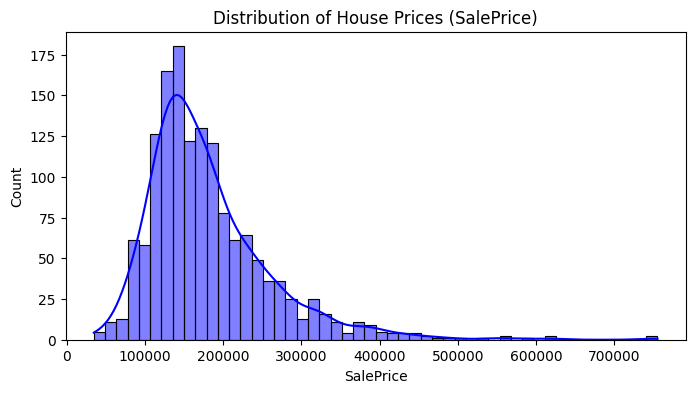

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True, color='blue',bins=50)
plt.title('Distribution of House Prices (SalePrice)')
plt.show()

SalePrice shows a right-skewed distribution, indicating that most houses are priced in the lower ranger while a small number of high-priced properties create a long tail. This suggests a potential need for log tranformation in later modeling

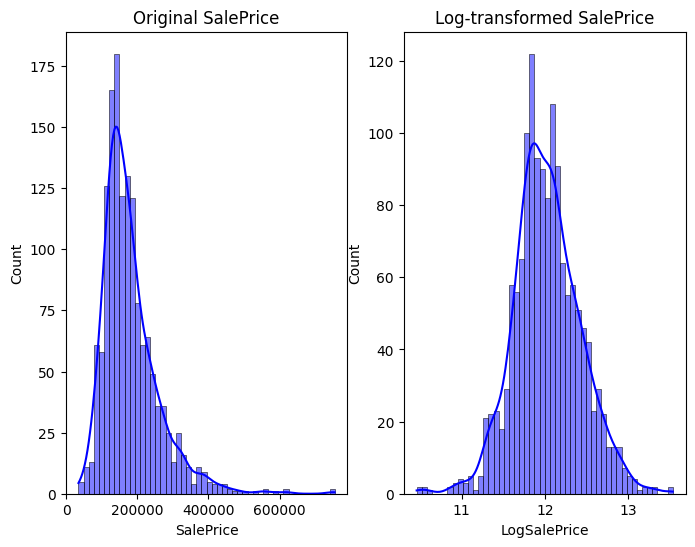

In [ ]:
df["LogSalePrice"] = np.log1p(df["SalePrice"])

plt.figure(figsize=(8, 6))
plt.subplot(1,2,1)
sns.histplot(df["SalePrice"],kde=True, color="blue", bins=50)
plt.title("Original SalePrice")

plt.subplot(1,2,2)
sns.histplot(df["LogSalePrice"],kde=True, color="blue", bins=50)
plt.title("Log-transformed SalePrice")

plt.show()

After log tranformation, the distribution  of SalePrice becomes more symmetric and closer to a normal distribution. This transformation reduces the influence of extreme high-priced properties, which may help improve model stability in later regression analysis.

---
### 2.2. Analyzing the relationship between SalePrice and another key factors
#### 2.2.1. OveralQual

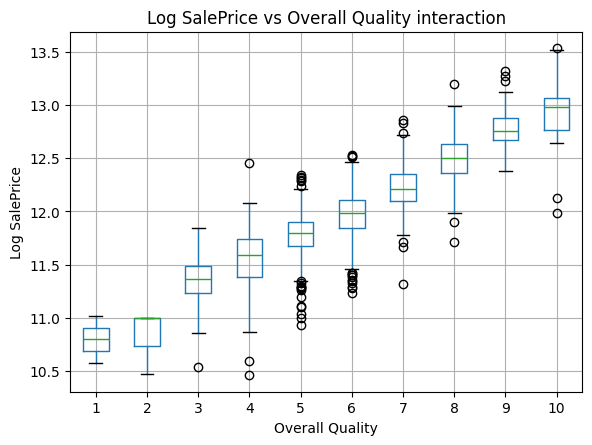

In [ ]:
df.boxplot(column="LogSalePrice",by="OverallQual")
plt.title("Log SalePrice vs Overall Quality interaction")
plt.suptitle("")
plt.xlabel("Overall Quality")
plt.ylabel("Log SalePrice")
plt.show()

I use a boxplot to examine the relationship between the categorical feature `Overall Quality` and the target variable `Log SalePrice`

#### Key Findings:
- Strong positive correlation: There is a clear trend; as the quality score increases, the meadian sale price rises accordingly. This suggests `OverallQual` will be a significant predictor for our model.
- Box characteristics & Variance:
	- **Quality 2 Skewness**: The median line is positioned near the top of the box, indicating a left-skewed distribution within this group. Most houses in this category are priced at the higher end of its range.
	- **High Variability**: Levels 5,6 and 7 exhibit the largest **Interquartile Range(IQR)**, representing higher price volatility in the mid-range market.
- **Outlier Detection**: Multiple outliers appear below the whiskers in levels 4 through 7.


---
#### 2.2.2. GrLivArea

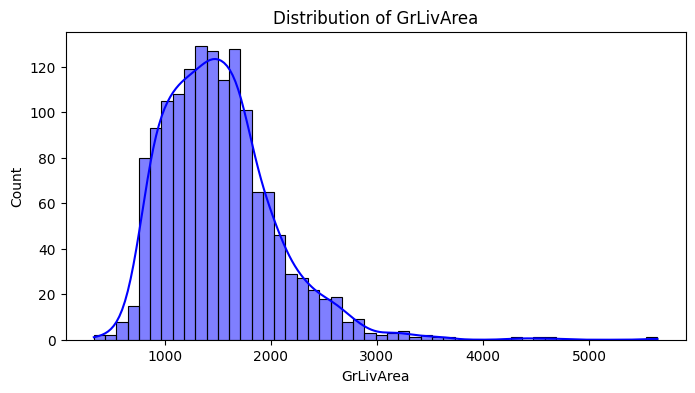

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['GrLivArea'], kde=True, color='blue',bins=50)
plt.title('Distribution of GrLivArea')
plt.show()

 Similar to the target variable, living area is right-skewed. Applying a log transformation helps stabilize variance and capture the price elasticity.

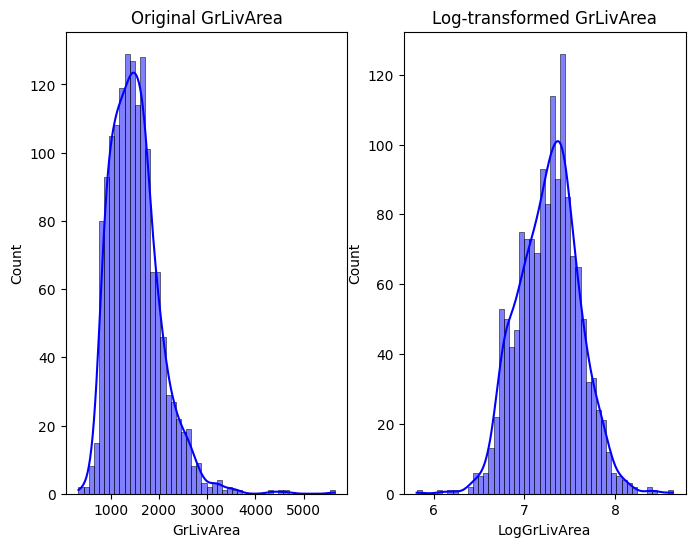

In [ ]:
df["LogGrLivArea"] = np.log1p(df["GrLivArea"])

plt.figure(figsize=(8, 6))
plt.subplot(1,2,1)
sns.histplot(df["GrLivArea"],kde=True, color="blue", bins=50)
plt.title("Original GrLivArea")
plt.subplot(1,2,2)
sns.histplot(df["LogGrLivArea"],kde=True, color="blue", bins=50)
plt.title("Log-transformed GrLivArea")

plt.show()

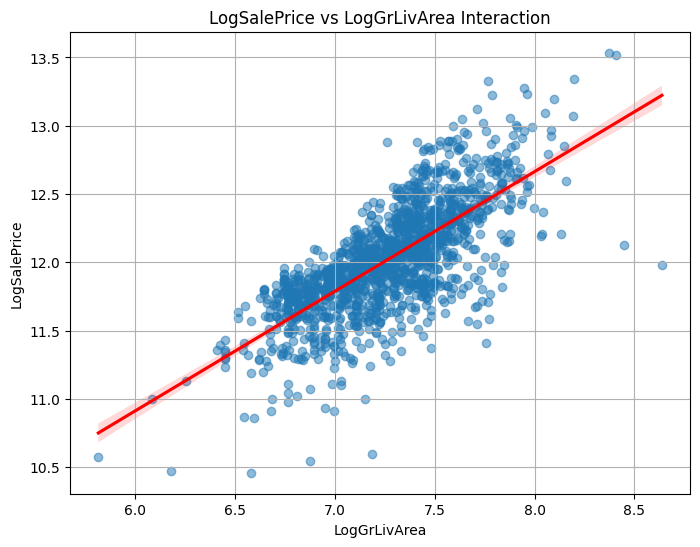

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='LogGrLivArea', y='LogSalePrice', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('LogSalePrice vs LogGrLivArea Interaction')
plt.grid(True)
plt.show()

---
### 2.2.3. Multiple `LogGrLivArea` and `OveralQual`

In [ ]:
df['Quality_Weighted_Area'] = df['LogGrLivArea'] * df['OverallQual']

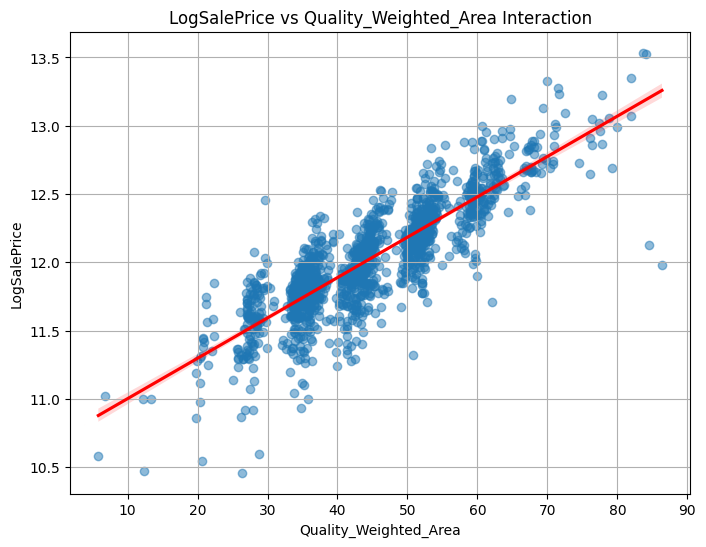

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='Quality_Weighted_Area', y='LogSalePrice', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('LogSalePrice vs Quality_Weighted_Area Interaction')
plt.grid(True)
plt.show()

#### Insight
- **Observation**: The scatter plot between Quality_Weighted_Area and LogSalePrice reveals two distinct outliers located in the bottom-right corner of the distribution.
- **Decision**: I have decided to remove these two observations to ensure the model captures the true underlying relationship of the residential housing market.

In [ ]:
df = df.drop(df[(df['Quality_Weighted_Area'] > 80) & (df['LogSalePrice'] < 12.5)].index)

---
#### 2.2.2. Categorical Features
Given the high dimensionality of categorical data (43 features), I selected a subset of features based on their practical impact on real estate value and data variance:
- `Neighborhood`, `ExterQual`, `KitchenQual`, and `BsmtQual` were retained as they reflect location and construction quality.
- `GarageFinish`,`CentralAir`, and `MSZoning` were included to capture essential structural and zoning information.

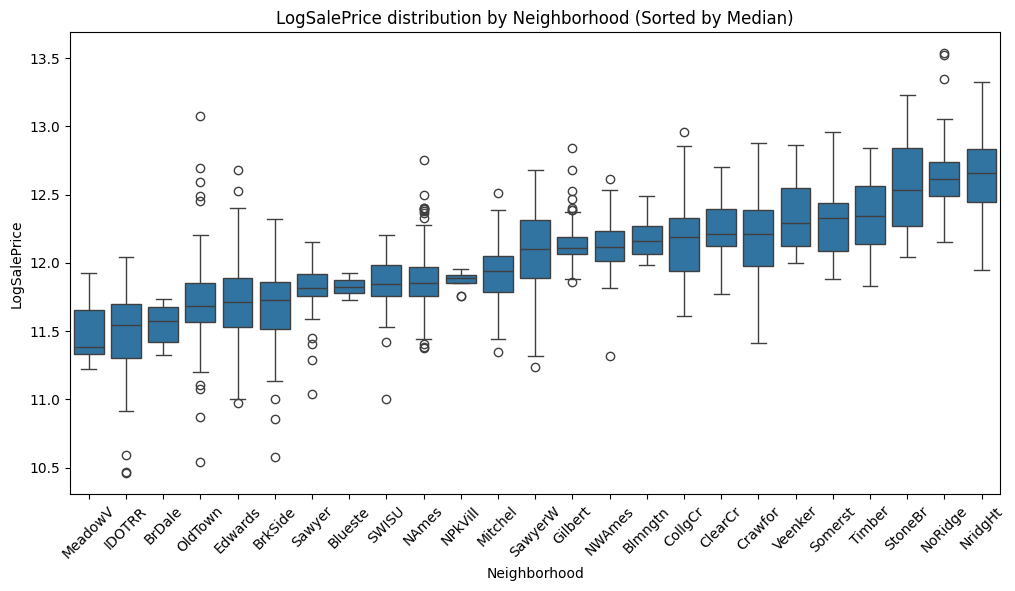

In [ ]:
neighborhood_order = df.groupby('Neighborhood')['LogSalePrice'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Neighborhood', y='LogSalePrice', order=neighborhood_order)
plt.xticks(rotation=45)
plt.title('LogSalePrice distribution by Neighborhood (Sorted by Median)')
plt.show()

In [ ]:
selected_cols = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish','CentralAir', 'MSZoning']
for col in selected_cols:
	print(f"--- Unique values in {col} ---")
	print(df[col].unique())
	print(f"Total unique: {df[col].nunique()}") # Đếm xem có bao nhiêu giá trị
	print("\n")


--- Unique values in Neighborhood ---
['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Total unique: 25


--- Unique values in ExterQual ---
['Gd' 'TA' 'Ex' 'Fa']
Total unique: 4


--- Unique values in KitchenQual ---
['Gd' 'TA' 'Ex' 'Fa']
Total unique: 4


--- Unique values in BsmtQual ---
['Gd' 'TA' 'Ex' nan 'Fa']
Total unique: 4


--- Unique values in GarageFinish ---
['RFn' 'Unf' 'Fin' nan]
Total unique: 3


--- Unique values in CentralAir ---
['Y' 'N']
Total unique: 2


--- Unique values in MSZoning ---
['RL' 'RM' 'C (all)' 'FV' 'RH']
Total unique: 5




- Ordinal Encoding for `ExterQal`, `KitchenQual`, `GarageFinish` and `BsmtQual`
- One-hot Encoding for `MSZoning`, `Neighborhood` and `CentralAir`

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

ord_cols = ['ExterQual', 'BsmtQual', 'KitchenQual', 'GarageFinish']
one_cols = ['MSZoning', 'CentralAir','Neighborhood']
ranking_type_1 = ['NA','Po','Fa', 'TA', 'Gd', 'Ex']
ranking_type_2 = ['NA','Unf','RFn', 'Fin']

hierarchies = [ranking_type_1, ranking_type_1, ranking_type_1, ranking_type_2]

ord_transformer = Pipeline(steps=[
	('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
	('ordinal', OrdinalEncoder(categories=hierarchies))
])

one_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ord_transformer, ord_cols),
        ('one', one_transformer, one_cols)
    ],
    remainder='passthrough'
)


/var/folders/z9/ccff43452zl58dshzch10z0c0000gn/T/ipykernel_79482/954804883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x= col,y = "LogSalePrice", palette='viridis')
/var/folders/z9/ccff43452zl58dshzch10z0c0000gn/T/ipykernel_79482/954804883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x= col,y = "LogSalePrice", palette='viridis')
/var/folders/z9/ccff43452zl58dshzch10z0c0000gn/T/ipykernel_79482/954804883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x= col,y = "LogSalePrice", palette='viridis')


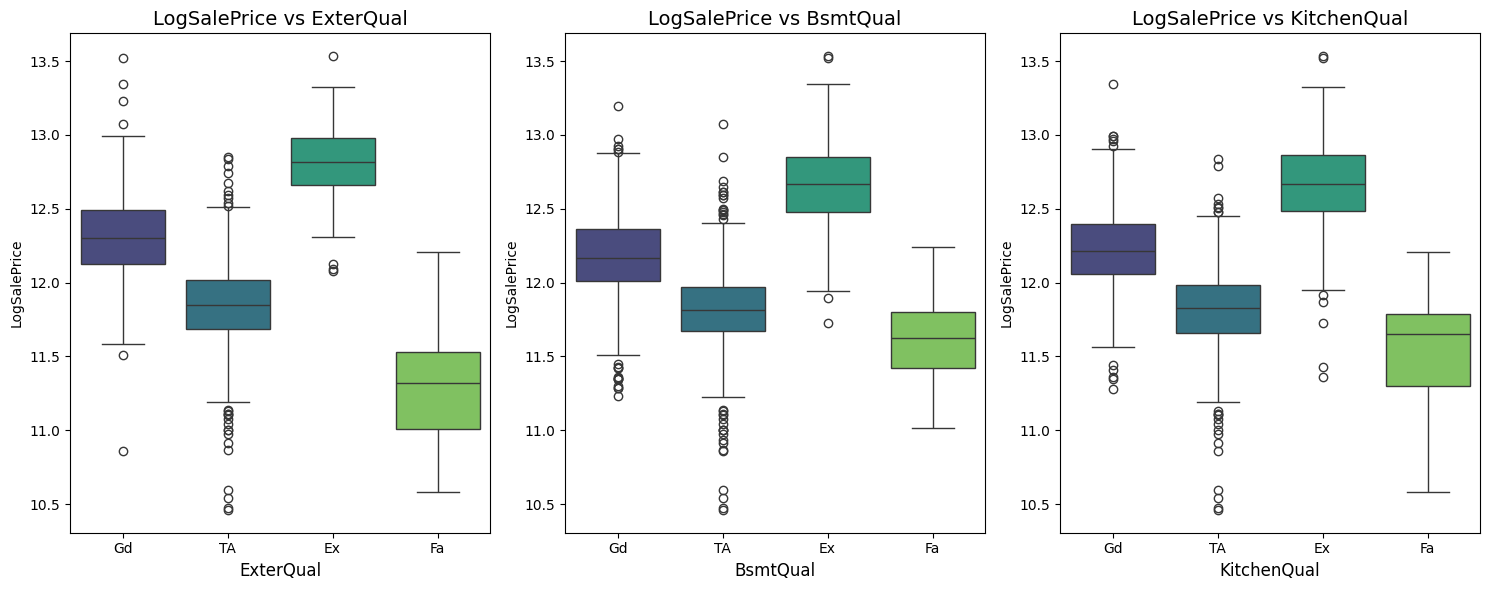

In [ ]:
features = ['ExterQual', 'BsmtQual', 'KitchenQual']
plt.figure(figsize=(15,6))

for i, col in enumerate(features):
	plt.subplot(1,3,i+1)
	sns.boxplot(data=df, x= col,y = "LogSalePrice", palette='viridis')
	plt.title(f'LogSalePrice vs {col}', fontsize=14)
	plt.xlabel(col, fontsize=12)

plt.tight_layout()

Analysis of Quality Features:
The boxplots illustrate a clear upward trend in $LogSalePrice$ as quality ratings improve from 2.0 to 5.0 across `ExterQual`, `BsmtQual`, and `KitchenQual`.

In [ ]:
cols_to_drop = ['SalePrice', 'GrLivArea']
df = df.drop(columns=cols_to_drop)

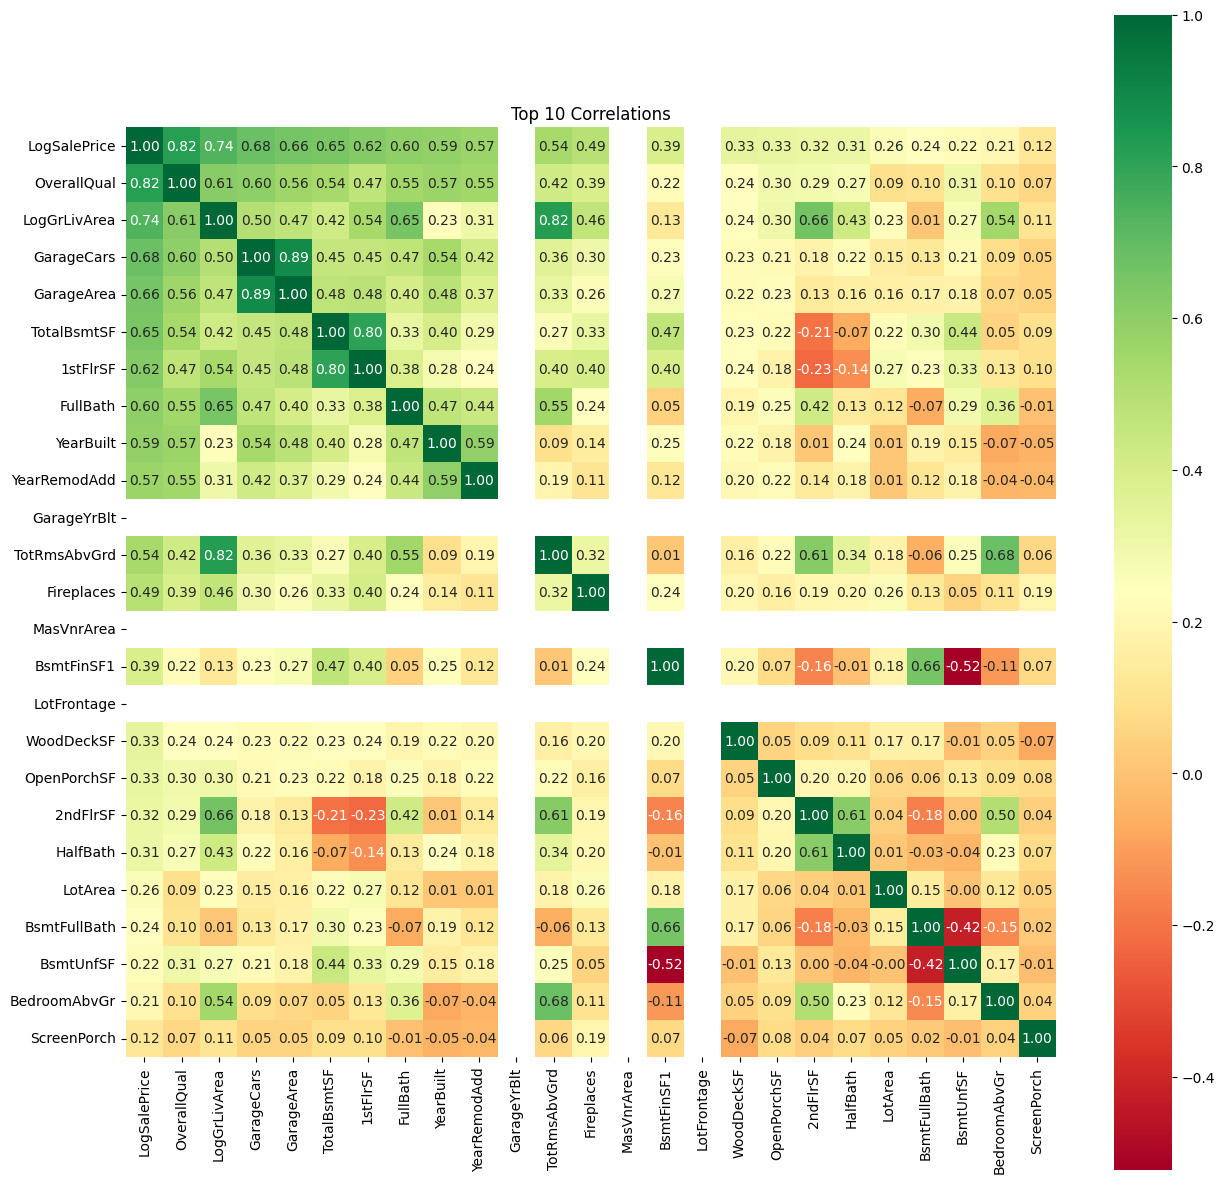

In [ ]:
corr_matrix = df_final.select_dtypes(include=[np.number]).corr()
k = 25
cols = corr_matrix.nlargest(k, 'LogSalePrice')['LogSalePrice'].index

cm = np.corrcoef(df[cols].values.T)

plt.figure(figsize=(15, 15))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
                 yticklabels=cols.values, xticklabels=cols.values, cmap="RdYlGn")
plt.title("Top 10 Correlations")
plt.show()

##### Insight
After visualizing the relationship between features using a Heatmap, I performed feature selection based on the Pearson correlation coefficient ($r$).
- Selection Criteria
	- Threshold: $|r| > 0.3$.
	- Rationale: Features with an absolute correlation coefficient greater than 0.3 are considered to have a moderate to strong relationship with the target variable (`SalePrice`). This threshold effectively filters out "noise" variables that do not contribute significantly to the model's predictive power.
- Handling Multicollinearity: To ensure the stability of the regression model, I examined pairs of independent variables with high mutual correlation ($|r| > 0.8$).
	- Action: Removed `GarageCars` (retained `GarageArea`) and `1stFlrSF` (retained `TotalBsmtSF`) to prevent redundancy and multicollinearity issues.
- Manual Filtering (Domain Knowledge Selection): Beyond statistical thresholds, I manually reviewed the remaining features and decided to drop certain variables based on domain knowledge and data quality.
	- Dropped Features: `YearRemodAdd`, `BsmtFinSF1`, `OpenPorchSF`, `2ndFlrSF`, `HalfBath`.
	- Rationale:
		- `YearRemodAdd`: In many cases, it is identical to `YearBuilt`. I chose to keep only `YearBuilt` to represent the overall age of the property.

		- `BsmtFinSF1`: This is a sub-component of basement area. I retained TotalBsmtSF as the primary indicator of basement value to avoid multicollinearity.

		- `2ndFlrSF`: Similarly, second-floor area is already captured in `GrLivArea` (General Living Area). Keeping both would create redundant information.

		- `OpenPorchSF`: The correlation with sale price was marginal, and its impact is often overshadowed by total living area or overall quality.

		- `HalfBath`: Although it had a marginal correlation ($|r| = 0.31$), I decided to drop it. In real estate valuation, a half-bath is rarely a primary driver of price compared to other architectural features. Removing it helps simplify the model without losing significant predictive power.


---

## 5. Conclusions

- **Target Transformation:** The `SalePrice` is right-skewed. Applying a **Log transformation** normalizes the distribution, which significantly improves the performance and meets the assumptions of linear regression models.
- **Feature Interaction:** Features such as living area (`LogGrLivArea`) and overall quality (`OverallQual`) show the strongest positive correlation with house prices. The newly created interaction term `Quality_Weighted_Area` effectively captures the non-linear synergy between size and quality.
- **Outlier Handling:** Based on visual analysis, extreme outliers (houses with massive area but unusually low price) were removed to prevent bias in the regression line.
- **Feature Filtering:** - Features with **more than 50% missing values** (e.g., `PoolQC`, `MiscFeature`) were dropped as they lack sufficient information.
    - Numerical features with a **correlation below 0.3** were excluded to reduce noise and prevent overfitting.
- **Feature Retention:** I retained 16 key features that demonstrate strong predictive power:
    - **Primary:** `SalePrice`
    - **Numerical:** `OverallQual`,`GrLivArea`, `GarageCars`, `TotalBsmtSF`, `FullBath`, `YearBuilt`, `TotRmsAbvGrd`, `Fireplaces`, `WoodDeckSF` and `OpenPorchSF`.
    - **Categorical:** `Neighborhood`, `MSZoning`, `ExterQual`, `KitchenQual`, `BsmtQual`, `GarageFinish`, and `CentralAir`.